In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from saidownscale import downscaling_utils, run_bcsd

# 0. Get data

In [2]:
RUN_PARAMETERS = {
    "gcm": "CESM2-WACCM",
    "train_period_start": 1978,
    "train_period_end": 2014,
    "predict_period_start": 2015,
    "predict_period_end": 2100,
    "var_name": "tas",
}

In [3]:
dict_all = run_bcsd.get_all_data(
    gcm=RUN_PARAMETERS["gcm"], var_name=RUN_PARAMETERS["var_name"], verbose=True
)

Loaded data: 1.04 seconds


In [4]:
for key in dict_all:
    print(key)

model_hist
obs
model_scenario


### Subset data to demo region (South Africa)

In [5]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

In [6]:
for key in dict_all:
    dict_all[key] = downscaling_utils.subset_space(
        dict_all[key], coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
    )

# 1. Preprocess data

In [7]:
RECHUNK_WORKFLOW = True  # flag: whether to rechunk data depending on the step
VERBOSE = True

In [8]:
dict_all = run_bcsd.preprocess_data(
    dict_all,
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
)

Rechunked obs to full space: 149.90 seconds
Interpolated obs to coarse grid: 53.19 seconds
Rechunked all to full time: 8.86 seconds
Detrended data: 11.80 seconds


# 2. Bias correct with quantile mapping

In [9]:
dict_all = run_bcsd.bias_correct(
    dict_all=dict_all,
    var_name=RUN_PARAMETERS["var_name"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
)

/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: Debiaser runs without time-information for at least one of obs, cm_hist or cm_future.
                        This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                        This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: Debiaser runs without time-information for at least one of obs, cm_hist or cm_future.
                        This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                        This might lead to slight numerical differences to the run with time 

Quantile mapped historical: 5.38 seconds
Quantile mapped historical: 6.09 seconds
Quantile mapped future: 5.27 seconds
Quantile mapped future: 7.28 seconds
Added back trend: 0.02 seconds


# 3. Downscale

In [10]:
dict_all = run_bcsd.spatially_disaggregate(
    dict_all=dict_all, verbose=VERBOSE, rechunk_workflow=RECHUNK_WORKFLOW
)

Rechunked to full space: 0.39 seconds
Downscaled historical: 8.71 seconds
Downscaled future: 10.08 seconds


# Look at results at Cape Town, South Africa

In [16]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x.item()),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y.item()),
)

In [17]:
dict_all_CT = {}
for key, ds in dict_all.items():
    print(key)
    ds_CT = ds.sel(lat=cape_town_y, lon=cape_town_x, method="nearest").compute()
    dict_all_CT[key] = ds_CT

model_hist
obs
model_scenario
obs_coarse
historical_scenario
scenario_detrended
scenario_trend
model_hist_debiased
scenario_debiased_detrended
scenario_debiased
model_hist_debiased_downscaled
scenario_debiased_downscaled


In [18]:
dict_all_CT["model_scenario_debiased"] = dict_all_CT["scenario_debiased"]
dict_all_CT["model_scenario_debiased_downscaled"] = dict_all_CT["scenario_debiased_downscaled"]

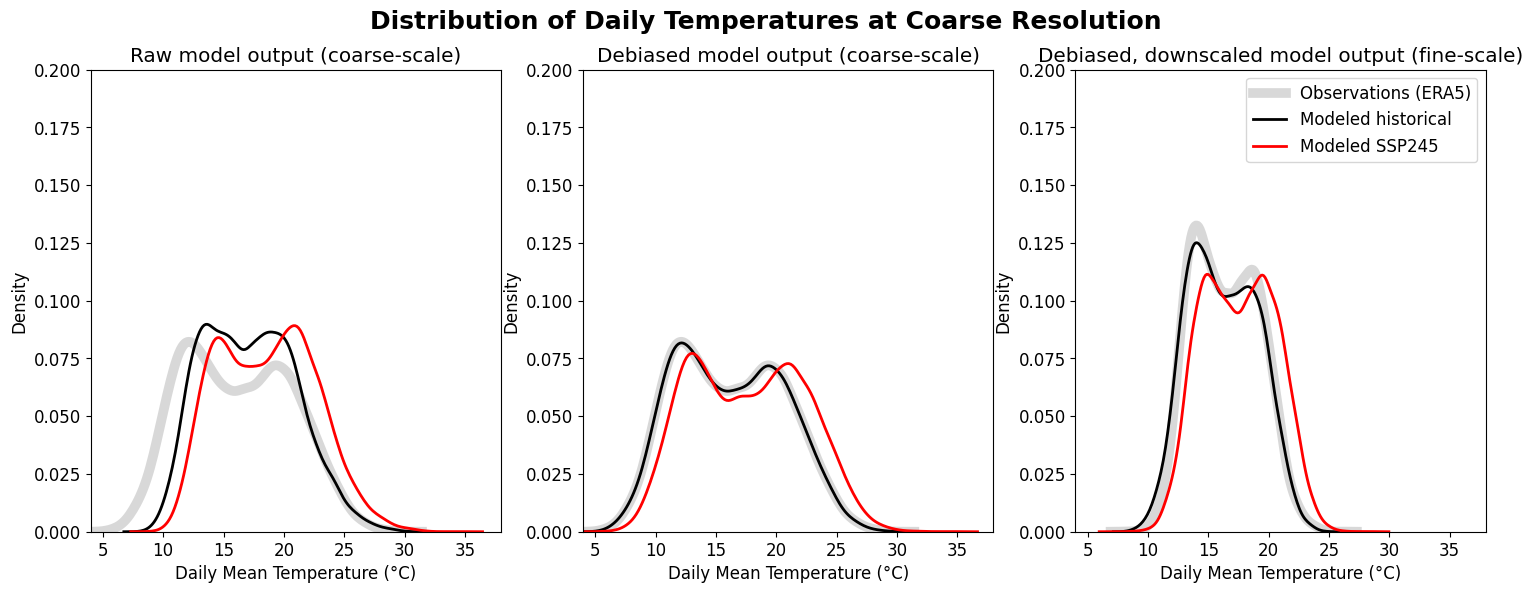

In [19]:
colors = ["black", "red"]
labels = ["Modeled historical", "Modeled SSP245"]
dataset_keys = ["model_hist", "model_scenario"]

plt.rcParams["font.size"] = 12


def format_subplot(res="coarse"):
    if res == "coarse":
        sns.kdeplot(
            dict_all_CT["obs_coarse"].as_numpy() - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    elif res == "fine":
        sns.kdeplot(
            dict_all_CT["obs"] - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    plt.ylim([0, 0.2])
    plt.xlim([4, 38])
    plt.xlabel("Daily Mean Temperature (°C)")


plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Raw model output (coarse-scale)")


plt.subplot(1, 3, 2)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased"] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Debiased model output (coarse-scale)")


plt.subplot(1, 3, 3)
format_subplot(res="fine")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased_downscaled"] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Debiased, downscaled model output (fine-scale)")

plt.suptitle(
    "Distribution of Daily Temperatures at Coarse Resolution",
    fontsize=18,
    fontweight="bold",
)

plt.legend(fontsize=12);